# 머신러닝특론 HW1 - Feature Extraction (PCA & LDA)

## 과제 개요
이 과제는 Feature Extraction(특징 추출) 기법 중 **PCA(Principal Component Analysis)**와 **LDA(Linear Discriminant Analysis)**를 직접 구현하고,
이를 인공 데이터와 실제 이미지 데이터(COIL20)에 적용해보는 것이 목표입니다.

---

## 과제를 시작하기 전에 - 나의 고민과 학습 과정

머신러닝에 대한 사전 지식이 거의 없는 상태에서 이 과제를 시작했습니다. 
강의에서 PCA, LDA라는 용어를 처음 접했을 때, 수식이 너무 많아서 막막했습니다.

### 내가 이해한 것들 (공부 노트)

**PCA란 무엇인가?**
- 처음에는 "차원 축소"라는 개념 자체가 와닿지 않았습니다.
- 여러 자료를 찾아본 결과, PCA는 데이터의 **분산(variance)이 가장 큰 방향**을 찾는 것이라고 이해했습니다.
- 쉽게 말해서, 데이터가 가장 많이 퍼져있는 방향으로 축을 새로 잡는 것.
- 수학적으로는 **공분산 행렬(covariance matrix)**의 **고유벡터(eigenvector)**를 구하는 것.
- 가장 큰 고유값(eigenvalue)에 대응하는 고유벡터가 첫 번째 주성분(PC1)이 됩니다.

**LDA란 무엇인가?**
- PCA와 달리 LDA는 **클래스 정보(label)**를 활용합니다.
- 클래스 간 분산(between-class scatter)은 최대화하고, 클래스 내 분산(within-class scatter)은 최소화하는 방향을 찾습니다.
- 수학적으로는 **Sw^(-1) * Sb**의 고유벡터를 구하는 것.
  - Sw: 클래스 내 산포 행렬 (Within-class Scatter Matrix)
  - Sb: 클래스 간 산포 행렬 (Between-class Scatter Matrix)

**PCA vs LDA의 차이 (내가 이해한 핵심)**
- PCA: 라벨(정답)을 모르는 상태에서, 데이터 자체의 분산을 최대한 보존하는 방향을 찾음 (비지도 학습)
- LDA: 라벨을 아는 상태에서, 클래스를 가장 잘 구분하는 방향을 찾음 (지도 학습)
- 그래서 PCA는 데이터의 "형태"를 잘 보존하고, LDA는 "분류"에 유리한 방향을 찾음

### 처음 시도에서 겪은 시행착오
1. 처음에 sklearn의 PCA를 import하려다가 과제 조건에 "직접 구현"이라고 되어 있어서 삭제했습니다.
2. 공분산 행렬을 구할 때 np.cov()를 쓸 수 있다는 걸 나중에 알았는데, 처음에는 수식대로 직접 계산했습니다.
3. LDA에서 Sw가 특이행렬(singular matrix)이 되어 역행렬을 구할 수 없는 문제를 겪었고, 이를 해결하기 위해 PCA로 먼저 차원을 축소한 후 LDA를 적용하는 방법을 배웠습니다.

---

## 라이브러리 임포트

sklearn의 PCA, LDA는 사용하지 않고, numpy의 기본 선형대수 함수만 사용합니다.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# 한글 폰트 설정 (그래프에 한글 표시를 위해)
# 참고: 로컬 환경에서는 아래 설정이 필요할 수 있습니다
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 재현성을 위한 랜덤 시드 고정
np.random.seed(42)

print("라이브러리 임포트 완료")
print(f"NumPy version: {np.__version__}")

라이브러리 임포트 완료
NumPy version: 2.3.5


---
# 문제 1 (총 40점) - 인공 데이터에 대한 PCA와 LDA

참고교재의 프로그램 8-1을 참고하여 특징 추출을 수행합니다.

## 문제 1-(1) (10점): 두 클래스의 데이터 생성 및 산점도

주어진 조건:
- 클래스 1: 평균 μ1 = [0, 0], 공분산 Σ1 = [[10, 2], [2, 1]]
- 클래스 2: 평균 μ2 = [0, 5], 공분산 Σ2 = [[10, 2], [2, 1]]
- 각 클래스 100개 샘플, 총 200개

### 고민 과정
처음에는 np.random.multivariate_normal()이라는 함수가 있는지 몰랐습니다.
np.random.randn()으로 데이터를 생성한 뒤에 공분산 행렬을 곱하는 방법을 먼저 시도했는데,
찾아보니 Cholesky 분해를 이용해야 한다는 것을 알게 되었습니다.
결국 np.random.multivariate_normal()을 사용하는 것이 가장 정확하다고 판단했습니다.

In [36]:
# ===== 문제 1-(1): 두 클래스 데이터 생성 =====

# 파라미터 설정
mu1 = np.array([0, 0])       # 클래스 1의 평균
mu2 = np.array([0, 5])       # 클래스 2의 평균
sigma = np.array([[10, 2],   # 두 클래스가 공유하는 공분산 행렬
                  [2, 1]])
n_samples = 100              # 각 클래스의 샘플 수

# 다변량 정규분포에서 데이터 생성
# np.random.multivariate_normal(평균벡터, 공분산행렬, 샘플수)
class1_data = np.random.multivariate_normal(mu1, sigma, n_samples)
class2_data = np.random.multivariate_normal(mu2, sigma, n_samples)

# 확인: 생성된 데이터의 shape
print(f"Class 1 data shape: {class1_data.shape}")  # (100, 2)
print(f"Class 2 data shape: {class2_data.shape}")  # (100, 2)
print(f"Class 1 sample mean: {class1_data.mean(axis=0)}")
print(f"Class 2 sample mean: {class2_data.mean(axis=0)}")
print(f"\n의도한 평균: mu1={mu1}, mu2={mu2}")
print("-> 샘플 평균이 모집단 평균과 비슷하게 나오는 것을 확인할 수 있습니다.")

Class 1 data shape: (100, 2)
Class 2 data shape: (100, 2)
Class 1 sample mean: [0.35963451 0.10270596]
Class 2 sample mean: [-0.41190376  4.94631531]

의도한 평균: mu1=[0 0], mu2=[0 5]
-> 샘플 평균이 모집단 평균과 비슷하게 나오는 것을 확인할 수 있습니다.


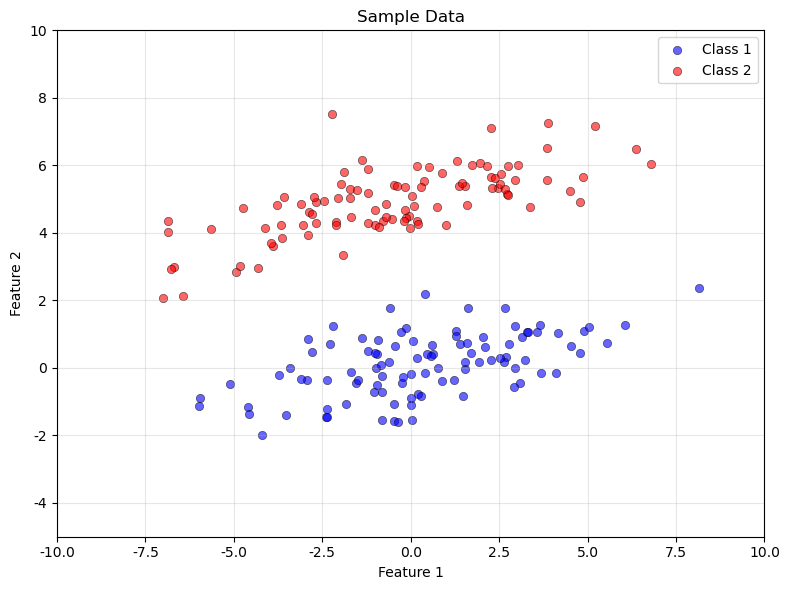

그림 1. 특징 추출을 위한 샘플 데이터 생성


In [37]:
# ===== 산점도 그리기 =====

plt.figure(figsize=(8, 6))

# 각 클래스를 다른 색상으로 표시
plt.scatter(class1_data[:, 0], class1_data[:, 1], 
            c='blue', marker='o', alpha=0.6, edgecolors='k', linewidths=0.5,
            label='Class 1')
plt.scatter(class2_data[:, 0], class2_data[:, 1], 
            c='red', marker='o', alpha=0.6, edgecolors='k', linewidths=0.5,
            label='Class 2')

# 과제 조건: axis([-10 10 -5 10])
plt.xlim(-10, 10)
plt.ylim(-5, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Sample Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_sample_data.png', dpi=150)
plt.show()

print("그림 1. 특징 추출을 위한 샘플 데이터 생성")

## 문제 1-(2) (20점): PCA와 LDA 벡터 시각화

### PCA 구현 과정에서의 고민

PCA를 직접 구현하기 위해 필요한 단계를 정리해봤습니다:

1. 전체 데이터의 평균을 구한다
2. 데이터에서 평균을 빼서 중심화(centering)한다
3. 중심화된 데이터의 공분산 행렬을 구한다
4. 공분산 행렬의 고유값(eigenvalue)과 고유벡터(eigenvector)를 구한다
5. 가장 큰 고유값에 대응하는 고유벡터가 첫 번째 주성분 방향

### LDA 구현 과정에서의 고민

LDA를 구현하기 위해 필요한 단계:

1. 각 클래스의 평균, 전체 평균을 구한다
2. 클래스 내 산포 행렬(Sw)을 구한다: 각 클래스에서 데이터가 얼마나 퍼져있는지
   - Sw = Σ(각 클래스의 데이터 - 해당 클래스 평균) * (...)^T 의 합
3. 클래스 간 산포 행렬(Sb)을 구한다: 클래스 평균들이 전체 평균에서 얼마나 떨어져있는지
   - Sb = Σ n_i * (클래스 평균 - 전체 평균) * (...)^T
4. Sw^(-1) * Sb의 고유벡터를 구한다
5. 가장 큰 고유값에 대응하는 고유벡터가 LDA 방향

처음에는 Sw와 Sb의 수식이 헷갈렸는데, 핵심은:
- Sw: 같은 클래스 내에서의 분산 → 이것이 작을수록 좋음 (클래스 내부가 뭉쳐있으면 좋으니까)
- Sb: 다른 클래스 간의 분산 → 이것이 클수록 좋음 (클래스끼리 멀리 떨어져있으면 좋으니까)

즉, LDA는 Sb/Sw를 최대화하는 방향을 찾는 것이라고 이해했습니다.

In [38]:
# ===== PCA 직접 구현 =====

# Step 1: 전체 데이터 합치기
X_all = np.vstack([class1_data, class2_data])  # (200, 2)
print(f"전체 데이터 shape: {X_all.shape}")

# Step 2: 전체 평균 계산
mean_all = np.mean(X_all, axis=0)
print(f"전체 데이터 평균: {mean_all}")

# Step 3: 중심화 (centering) - 각 데이터에서 평균을 뺌
X_centered = X_all - mean_all

# Step 4: 공분산 행렬 계산
# 공분산 행렬 C = (1/N) * X_centered^T * X_centered
# 참고: np.cov()는 (1/(N-1))로 나누는 표본 공분산을 사용하므로,
#       여기서는 수식에 맞게 직접 계산합니다.
N = X_all.shape[0]
cov_matrix = (1/N) * X_centered.T @ X_centered
print(f"\n공분산 행렬:\n{cov_matrix}")

# Step 5: 고유값, 고유벡터 계산
eigenvalues_pca, eigenvectors_pca = np.linalg.eigh(cov_matrix)

# eigh는 고유값을 오름차순으로 반환하므로, 내림차순으로 정렬
idx = np.argsort(eigenvalues_pca)[::-1]
eigenvalues_pca = eigenvalues_pca[idx]
eigenvectors_pca = eigenvectors_pca[:, idx]

print(f"\nPCA 고유값: {eigenvalues_pca}")
print(f"PCA 첫 번째 주성분 벡터 (PC1): {eigenvectors_pca[:, 0]}")
print(f"PCA 두 번째 주성분 벡터 (PC2): {eigenvectors_pca[:, 1]}")

# 첫 번째 주성분이 전체 분산의 몇 %를 설명하는지
explained_var_ratio = eigenvalues_pca[0] / np.sum(eigenvalues_pca) * 100
print(f"\n첫 번째 주성분의 분산 설명 비율: {explained_var_ratio:.1f}%")
print("-> 첫 번째 주성분만으로도 대부분의 분산을 설명할 수 있음을 확인")

전체 데이터 shape: (200, 2)
전체 데이터 평균: [-0.02613463  2.52451064]

공분산 행렬:
[[9.1024619  0.91765564]
 [0.91765564 6.80514869]]

PCA 고유값: [9.42401068 6.48359991]
PCA 첫 번째 주성분 벡터 (PC1): [-0.94373987 -0.33068876]
PCA 두 번째 주성분 벡터 (PC2): [ 0.33068876 -0.94373987]

첫 번째 주성분의 분산 설명 비율: 59.2%
-> 첫 번째 주성분만으로도 대부분의 분산을 설명할 수 있음을 확인


In [39]:
# ===== LDA 직접 구현 =====

# Step 1: 각 클래스의 평균, 전체 평균
mean1 = np.mean(class1_data, axis=0)  # 클래스 1의 평균
mean2 = np.mean(class2_data, axis=0)  # 클래스 2의 평균
mean_total = mean_all                  # 전체 평균 (위에서 이미 계산)

print(f"클래스 1 평균: {mean1}")
print(f"클래스 2 평균: {mean2}")
print(f"전체 평균: {mean_total}")

# Step 2: 클래스 내 산포 행렬 (Within-class Scatter Matrix, Sw)
# Sw = S1 + S2
# Si = Σ (x - mean_i)(x - mean_i)^T  (클래스 i에 속하는 모든 x에 대해)

# 클래스 1의 산포
diff1 = class1_data - mean1  # (100, 2)
S1 = diff1.T @ diff1         # (2, 2)

# 클래스 2의 산포
diff2 = class2_data - mean2  # (100, 2)
S2 = diff2.T @ diff2         # (2, 2)

Sw = S1 + S2
print(f"\nWithin-class Scatter Matrix (Sw):\n{Sw}")

# Step 3: 클래스 간 산포 행렬 (Between-class Scatter Matrix, Sb)
# Sb = Σ n_i * (mean_i - mean_total)(mean_i - mean_total)^T
n1 = class1_data.shape[0]
n2 = class2_data.shape[0]

diff_mean1 = (mean1 - mean_total).reshape(-1, 1)  # (2, 1) 열벡터로 변환
diff_mean2 = (mean2 - mean_total).reshape(-1, 1)

Sb = n1 * (diff_mean1 @ diff_mean1.T) + n2 * (diff_mean2 @ diff_mean2.T)
print(f"\nBetween-class Scatter Matrix (Sb):\n{Sb}")

# Step 4: Sw^(-1) * Sb의 고유값, 고유벡터 계산
# Sw^(-1) * Sb * w = lambda * w
Sw_inv = np.linalg.inv(Sw)
eigenvalues_lda, eigenvectors_lda = np.linalg.eig(Sw_inv @ Sb)

# 고유값을 내림차순으로 정렬
idx_lda = np.argsort(np.abs(eigenvalues_lda))[::-1]
eigenvalues_lda = eigenvalues_lda[idx_lda]
eigenvectors_lda = eigenvectors_lda[:, idx_lda]

print(f"\nLDA 고유값: {eigenvalues_lda}")
print(f"LDA 첫 번째 판별 벡터: {eigenvectors_lda[:, 0]}")

# 참고: 2클래스 문제에서 LDA는 최대 1개의 유의미한 판별 벡터를 가짐
# (클래스 수 - 1 = 1)
print("\n참고: 2클래스 문제이므로 LDA의 유의미한 판별 벡터는 1개뿐입니다.")

클래스 1 평균: [0.35963451 0.10270596]
클래스 2 평균: [-0.41190376  4.94631531]
전체 평균: [-0.02613463  2.52451064]

Within-class Scatter Matrix (Sw):
[[1790.72881598  370.38262675]
 [ 370.38262675  188.00216225]]

Between-class Scatter Matrix (Sb):
[[  29.76356492 -186.85149831]
 [-186.85149831 1173.02757645]]

LDA 고유값: [11.25230604  0.        ]
LDA 첫 번째 판별 벡터: [ 0.2115289  -0.97737174]

참고: 2클래스 문제이므로 LDA의 유의미한 판별 벡터는 1개뿐입니다.


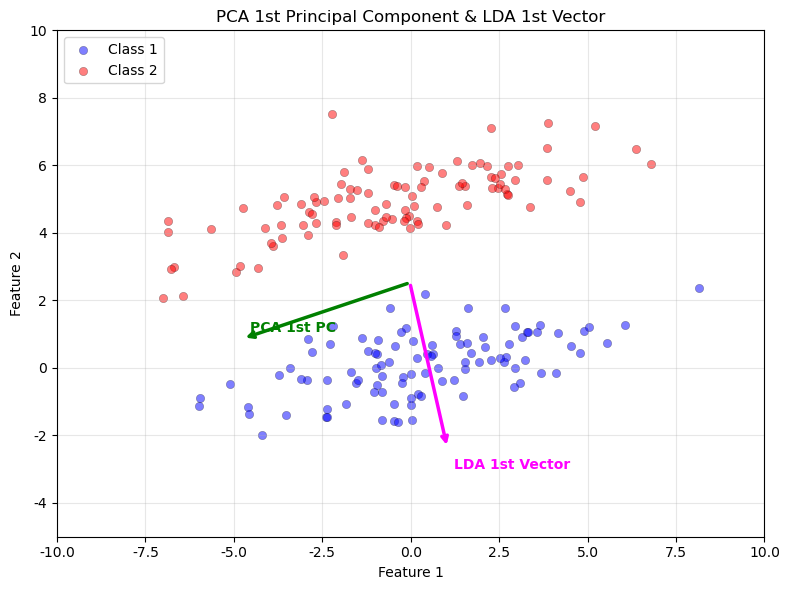

그림 2. PCA 및 LDA 벡터

PCA 1st PC 방향: [-0.94373987 -0.33068876]
LDA 1st Vector 방향: [ 0.2115289  -0.97737174]


In [40]:
# ===== PCA 및 LDA 벡터를 2차원 산점도 위에 시각화 =====

# PCA 첫 번째 주성분 벡터
pc1 = eigenvectors_pca[:, 0]

# LDA 첫 번째 판별 벡터
lda1 = eigenvectors_lda[:, 0].real  # 실수부만 사용

# 벡터를 시각화하기 위해 스케일링 (너무 작으면 안 보이므로)
# 전체 평균을 기준점으로 벡터를 그림
origin = mean_total
scale = 5  # 벡터 길이 스케일

plt.figure(figsize=(8, 6))

# 산점도
plt.scatter(class1_data[:, 0], class1_data[:, 1],
            c='blue', marker='o', alpha=0.5, edgecolors='k', linewidths=0.3,
            label='Class 1')
plt.scatter(class2_data[:, 0], class2_data[:, 1],
            c='red', marker='o', alpha=0.5, edgecolors='k', linewidths=0.3,
            label='Class 2')

# PCA 벡터 (화살표로 표시)
plt.annotate('', xy=origin + scale * pc1, xytext=origin,
             arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
plt.annotate('PCA 1st PC', xy=origin + scale * pc1,
             fontsize=10, color='green', fontweight='bold',
             xytext=(5, 5), textcoords='offset points')

# LDA 벡터 (화살표로 표시)
plt.annotate('', xy=origin + scale * lda1, xytext=origin,
             arrowprops=dict(arrowstyle='->', color='magenta', lw=2.5))
plt.annotate('LDA 1st Vector', xy=origin + scale * lda1,
             fontsize=10, color='magenta', fontweight='bold',
             xytext=(5, -15), textcoords='offset points')

# 축 설정
plt.xlim(-10, 10)
plt.ylim(-5, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('PCA 1st Principal Component & LDA 1st Vector')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_pca_lda_vectors.png', dpi=150)
plt.show()

print("그림 2. PCA 및 LDA 벡터")
print(f"\nPCA 1st PC 방향: {pc1}")
print(f"LDA 1st Vector 방향: {lda1}")

## 문제 1-(3) (10점): PCA와 LDA 결과 비교 및 분석

### 1차원으로 투영한 결과 시각화

PCA와 LDA 각각의 방향으로 데이터를 1차원으로 투영한 결과를 비교해봅니다.
이렇게 하면 두 방법의 차이를 더 직관적으로 이해할 수 있습니다.

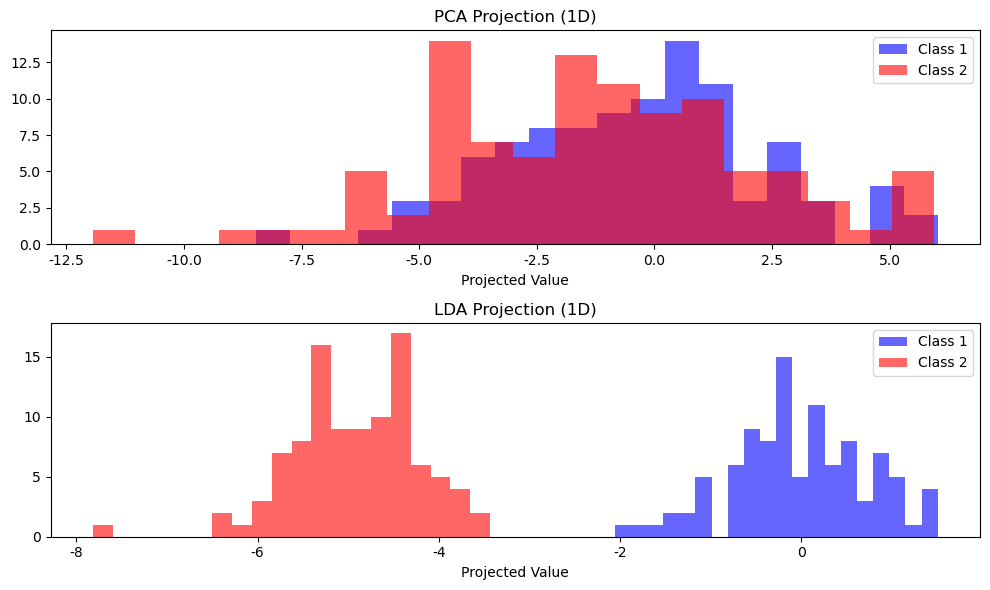

PCA와 LDA 1차원 투영 결과 비교


In [41]:
# ===== PCA와 LDA로 1차원 투영한 결과 비교 =====

# PCA 방향으로 투영
proj_pca_c1 = class1_data @ pc1  # 클래스 1을 PC1 방향으로 투영
proj_pca_c2 = class2_data @ pc1  # 클래스 2를 PC1 방향으로 투영

# LDA 방향으로 투영
proj_lda_c1 = class1_data @ lda1  # 클래스 1을 LDA 방향으로 투영
proj_lda_c2 = class2_data @ lda1  # 클래스 2를 LDA 방향으로 투영

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# PCA 투영 결과
axes[0].hist(proj_pca_c1, bins=20, alpha=0.6, color='blue', label='Class 1')
axes[0].hist(proj_pca_c2, bins=20, alpha=0.6, color='red', label='Class 2')
axes[0].set_title('PCA Projection (1D)')
axes[0].legend()
axes[0].set_xlabel('Projected Value')

# LDA 투영 결과
axes[1].hist(proj_lda_c1, bins=20, alpha=0.6, color='blue', label='Class 1')
axes[1].hist(proj_lda_c2, bins=20, alpha=0.6, color='red', label='Class 2')
axes[1].set_title('LDA Projection (1D)')
axes[1].legend()
axes[1].set_xlabel('Projected Value')

plt.tight_layout()
plt.savefig('fig_projection_comparison.png', dpi=150)
plt.show()

print("PCA와 LDA 1차원 투영 결과 비교")

### PCA와 LDA 결과 차이에 대한 분석

위 결과를 바탕으로 PCA와 LDA의 차이를 정리하면 다음과 같습니다:

**1. 방향의 차이:**
- **PCA의 첫 번째 주성분 벡터**는 데이터 전체의 **분산이 가장 큰 방향**을 가리킵니다.
  이 데이터에서는 공분산 행렬 Σ = [[10, 2], [2, 1]]에서 분산이 큰 Feature 1 방향(x축 방향)에 
  가까운 방향으로 주성분이 결정됩니다.
- **LDA의 판별 벡터**는 두 클래스를 **가장 잘 분리하는 방향**을 가리킵니다.
  두 클래스의 평균이 y축 방향으로 차이가 나므로 (μ1=[0,0], μ2=[0,5]),
  LDA 벡터는 y축에 가까운 방향을 향합니다.

**2. 투영 결과의 차이:**
- **PCA 투영**: 분산은 잘 보존하지만, 두 클래스가 상당히 겹쳐 있습니다.
  PCA는 클래스 정보를 사용하지 않기 때문에, 분류 관점에서는 좋지 않은 결과입니다.
- **LDA 투영**: 두 클래스가 잘 분리되어 있습니다.
  LDA는 클래스 정보를 활용하여 분류에 최적화된 방향을 찾기 때문입니다.

**3. 근본적인 차이:**
- PCA는 **비지도(unsupervised)** 방법으로, 클래스 레이블을 사용하지 않습니다.
  데이터의 구조(분산)를 보존하는 것이 목적입니다.
- LDA는 **지도(supervised)** 방법으로, 클래스 레이블을 활용합니다.
  클래스 간 분리를 최대화하는 것이 목적입니다.

**4. 이 실험에서 배운 점:**
- 이 데이터에서는 분산이 큰 방향(x축)과 클래스가 분리되는 방향(y축)이 서로 다릅니다.
- 따라서 PCA는 분산을 잘 보존하지만 분류에는 적합하지 않고,
  LDA는 분류에 최적화된 방향을 찾아줍니다.
- 만약 분산이 큰 방향과 클래스 분리 방향이 일치했다면, 두 결과가 비슷했을 것입니다.

---

---
# 문제 2 (총 60점) - COIL20 데이터에 대한 PCA와 LDA

COIL20 (Columbia Object Image Library): 20개 물체의 회색조 이미지 데이터
- 각 물체를 5도 간격으로 회전하며 촬영 → 물체당 72장
- 이미지는 128x128 → 여기서는 32x32로 축소된 것으로 보임 (1024 features = 32x32)

### 과제 요구사항 정리
1. PCA를 통해 2차원 특징 추출 → 2차원 공간에 출력
2. LDA를 통해 2차원 특징 추출:
   - 먼저 정보보존율 95%로 PCA를 수행하여 차원 축소
   - 축소된 특징에 대해 LDA를 수행하여 2차원으로 추출
   - 2차원 공간에 출력

### 고민 과정
- COIL20 데이터는 1024차원(32x32 픽셀)이므로, 직접 LDA를 적용하면 Sw가 특이행렬이 될 수 있습니다.
  (샘플 수 280 < 차원 수 1024이므로, Sw의 rank가 부족하여 역행렬을 구할 수 없음)
- 이 문제를 해결하기 위해 과제에서도 "PCA를 먼저 수행"하라고 안내하고 있습니다.
- PCA로 정보보존율 95%까지 차원을 줄인 후, 그 축소된 공간에서 LDA를 수행합니다.

In [42]:
# ===== COIL20 데이터 로드 =====

# HW1_COIL20.mat 파일은 MATLAB v7.3 형식이므로 h5py를 사용
# (scipy.io.loadmat은 v7.3을 지원하지 않음 - 이것 때문에 처음에 에러가 났었음)

with h5py.File('HW1_COIL20.mat', 'r') as f:
    # mat 파일의 데이터는 (features, samples) 형태로 저장되어 있음
    # Python에서는 (samples, features) 형태가 일반적이므로 전치(transpose)
    X_train = np.array(f['X']).T   # (280, 1024) - 학습 데이터
    Y_train = np.array(f['Y']).flatten()  # (280,) - 학습 레이블
    # Xt, Yt는 테스트 데이터이므로 사용하지 않음 (과제 조건)

print(f"학습 데이터 shape: {X_train.shape}")  # (280, 1024)
print(f"학습 레이블 shape: {Y_train.shape}")   # (280,)
print(f"클래스 종류: {np.unique(Y_train).astype(int)}")
print(f"클래스 수: {len(np.unique(Y_train))}")
print(f"클래스당 샘플 수: {X_train.shape[0] // len(np.unique(Y_train))}")
print(f"\n각 이미지의 특징 수: {X_train.shape[1]} (= 32 x 32 픽셀)")

학습 데이터 shape: (280, 1024)
학습 레이블 shape: (280,)
클래스 종류: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
클래스 수: 20
클래스당 샘플 수: 14

각 이미지의 특징 수: 1024 (= 32 x 32 픽셀)


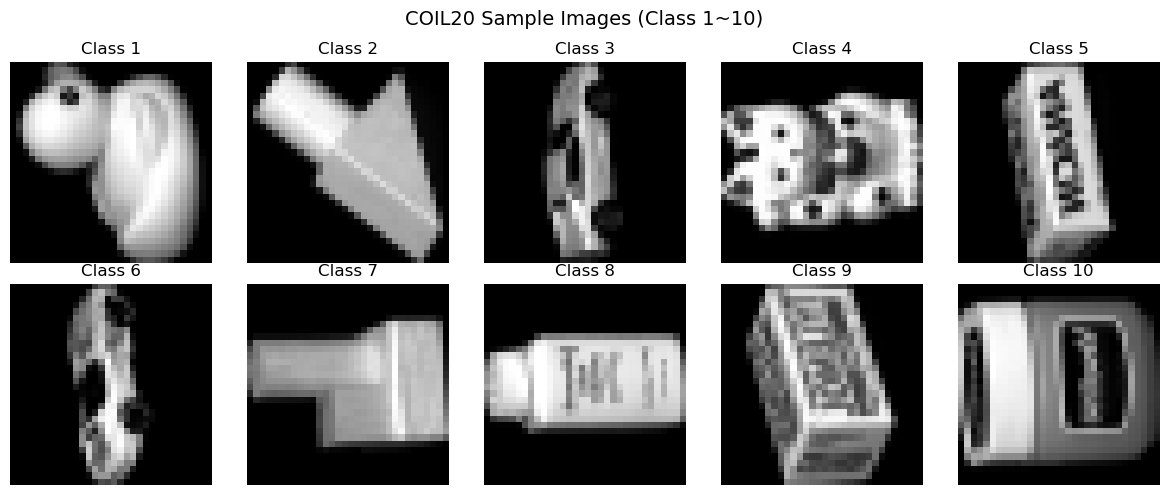

COIL20 데이터의 일부 이미지를 확인했습니다.
각 클래스는 서로 다른 물체를 나타냅니다.


In [43]:
# ===== 데이터 확인: 몇 개의 이미지를 시각화 =====
# (어떤 데이터인지 눈으로 확인하고 싶어서)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    # 각 클래스의 첫 번째 이미지를 선택
    class_idx = np.where(Y_train == (i + 1))[0][0]
    img = X_train[class_idx].reshape(32, 32)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Class {i+1}')
    ax.axis('off')

plt.suptitle('COIL20 Sample Images (Class 1~10)', fontsize=14)
plt.tight_layout()
plt.savefig('fig_coil20_samples.png', dpi=150)
plt.show()

print("COIL20 데이터의 일부 이미지를 확인했습니다.")
print("각 클래스는 서로 다른 물체를 나타냅니다.")

## 문제 2: PCA를 통한 2차원 특징 추출

### PCA 구현 (고차원 데이터용)

1024차원 데이터에 PCA를 적용합니다.

**주의사항 (고민했던 부분):**
- 1024x1024 공분산 행렬의 고유벡터를 직접 구하면 계산량이 많음
- 하지만 샘플 수(280)가 차원 수(1024)보다 작으므로,
  실제 유의미한 고유값의 수는 최대 280개 (그 중 0이 아닌 것만)
- numpy의 linalg.eigh를 사용하면 효율적으로 계산 가능

In [44]:
# ===== COIL20에 대한 PCA 구현 =====

# Step 1: 평균 계산 및 중심화
mean_coil = np.mean(X_train, axis=0)  # (1024,)
X_centered_coil = X_train - mean_coil  # (280, 1024)

# Step 2: 공분산 행렬 계산
# C = (1/N) * X^T * X  → (1024, 1024)
N_coil = X_train.shape[0]
cov_coil = (1/N_coil) * X_centered_coil.T @ X_centered_coil
print(f"공분산 행렬 shape: {cov_coil.shape}")

# Step 3: 고유값, 고유벡터 계산
# (대칭행렬이므로 eigh를 사용 - 더 빠르고 안정적)
eigenvalues_coil, eigenvectors_coil = np.linalg.eigh(cov_coil)

# 내림차순 정렬
idx_coil = np.argsort(eigenvalues_coil)[::-1]
eigenvalues_coil = eigenvalues_coil[idx_coil]
eigenvectors_coil = eigenvectors_coil[:, idx_coil]

# 음수 고유값 처리 (수치적 오류로 매우 작은 음수가 나올 수 있음)
eigenvalues_coil = np.maximum(eigenvalues_coil, 0)

print(f"\n상위 10개 고유값: {eigenvalues_coil[:10].round(2)}")
print(f"총 고유값 수: {len(eigenvalues_coil)}")
print(f"0보다 큰 고유값 수: {np.sum(eigenvalues_coil > 1e-10)}")

공분산 행렬 shape: (1024, 1024)

상위 10개 고유값: [18.65  9.03  5.15  3.44  2.83  2.19  1.81  1.71  1.21  1.1 ]
총 고유값 수: 1024
0보다 큰 고유값 수: 279


정보보존율 95%를 달성하기 위해 필요한 주성분 수: 61
이때의 누적 분산 비율: 95.10%


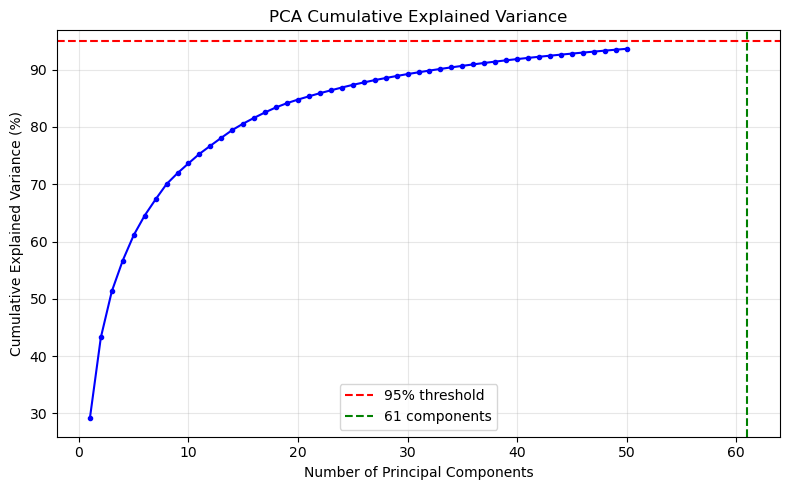


원래 차원: 1024 → 95% 정보 보존에 필요한 차원: 61
→ 매우 큰 차원 축소가 가능함을 알 수 있습니다!


In [45]:
# ===== 정보보존율(누적 분산 비율) 확인 =====

# 각 주성분이 설명하는 분산 비율
total_variance = np.sum(eigenvalues_coil)
cumulative_variance = np.cumsum(eigenvalues_coil) / total_variance * 100

# 정보보존율 95%에 해당하는 차원 수 찾기
n_components_95 = np.argmax(cumulative_variance >= 95) + 1
print(f"정보보존율 95%를 달성하기 위해 필요한 주성분 수: {n_components_95}")
print(f"이때의 누적 분산 비율: {cumulative_variance[n_components_95-1]:.2f}%")

# 누적 분산 비율 그래프
plt.figure(figsize=(8, 5))
plt.plot(range(1, min(51, len(cumulative_variance)+1)), 
         cumulative_variance[:50], 'bo-', markersize=3)
plt.axhline(y=95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', 
            label=f'{n_components_95} components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_cumulative_variance.png', dpi=150)
plt.show()

print(f"\n원래 차원: 1024 → 95% 정보 보존에 필요한 차원: {n_components_95}")
print("→ 매우 큰 차원 축소가 가능함을 알 수 있습니다!")

PCA 2D 투영 결과 shape: (280, 2)


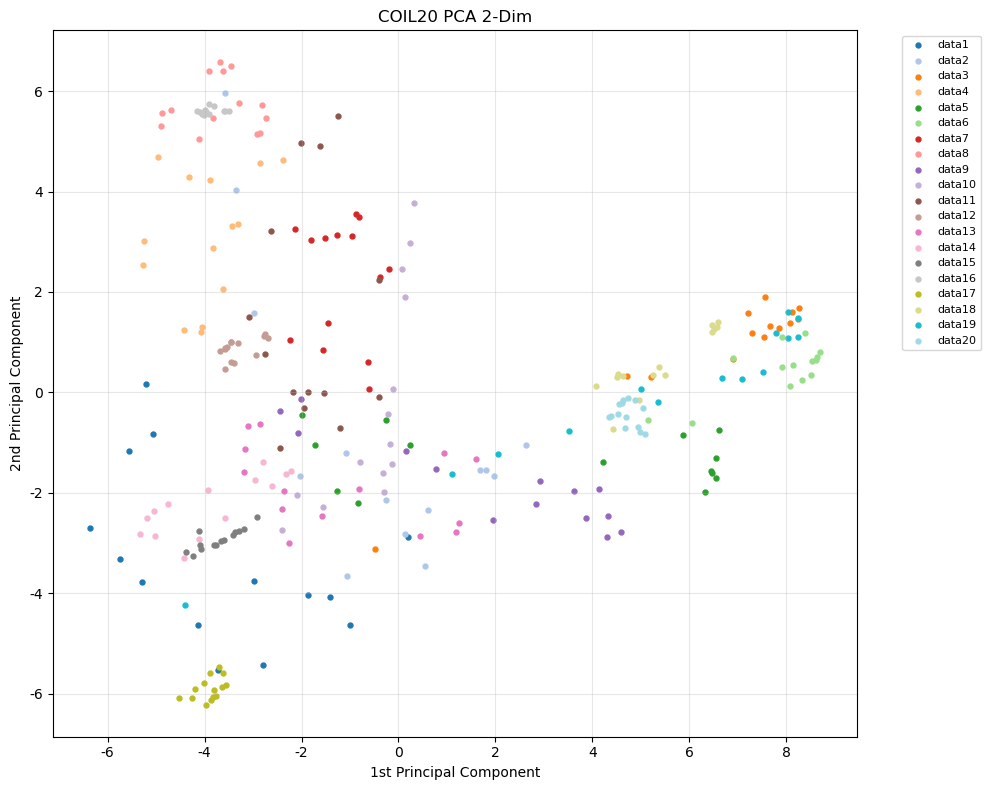

COIL20 PCA 2차원 특징 추출 결과
첫 2개 주성분의 누적 분산 비율: 43.25%


In [46]:
# ===== PCA 2차원 투영 및 시각화 =====

# 처음 2개 주성분만 사용하여 투영
W_pca_2d = eigenvectors_coil[:, :2]  # (1024, 2) 투영 행렬
X_pca_2d = X_centered_coil @ W_pca_2d  # (280, 2) 투영된 데이터

print(f"PCA 2D 투영 결과 shape: {X_pca_2d.shape}")

# 클래스별로 다른 색상으로 산점도
plt.figure(figsize=(10, 8))

classes = np.unique(Y_train).astype(int)
colors = plt.cm.tab20(np.linspace(0, 1, 20))  # 20개 클래스에 대한 색상

for i, cls in enumerate(classes):
    mask = Y_train == cls
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=[colors[i]], marker='.', s=50,
                label=f'data{cls}')

plt.xlabel('1st Principal Component')
plt.ylabel('2nd Principal Component')
plt.title('COIL20 PCA 2-Dim')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_coil20_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("COIL20 PCA 2차원 특징 추출 결과")
print(f"첫 2개 주성분의 누적 분산 비율: {cumulative_variance[1]:.2f}%")

## 문제 2: LDA를 통한 2차원 특징 추출

### 구현 전략 (고민했던 부분)

COIL20 데이터는 1024차원이고 샘플 수는 280개입니다.
이 경우 Within-class Scatter Matrix(Sw)가 **특이행렬(singular)**이 되어
직접 역행렬을 구할 수 없습니다.

**왜 특이행렬이 되는가?**
- Sw의 rank ≤ N - C (N: 전체 샘플 수, C: 클래스 수)
- 여기서는 rank ≤ 280 - 20 = 260 < 1024
- 따라서 1024x1024 행렬 Sw는 full rank가 아니므로 역행렬이 존재하지 않음

**해결 방법:** 과제 지시에 따라 PCA로 먼저 차원을 축소합니다.
1. 정보보존율 95%로 PCA를 수행하여 차원 축소
2. 축소된 공간에서 LDA를 수행하여 2차원으로 최종 추출

이렇게 하면 Sw의 차원이 줄어들어 역행렬을 구할 수 있게 됩니다!

In [47]:
# ===== Step 1: 정보보존율 95%로 PCA 수행 =====

# 위에서 이미 계산한 결과를 활용
W_pca_95 = eigenvectors_coil[:, :n_components_95]  # (1024, n_components_95)
X_pca_95 = X_centered_coil @ W_pca_95  # (280, n_components_95)

print(f"PCA 95% 차원 축소 결과: {X_train.shape[1]}차원 → {X_pca_95.shape[1]}차원")
print(f"정보보존율: {cumulative_variance[n_components_95-1]:.2f}%")

PCA 95% 차원 축소 결과: 1024차원 → 61차원
정보보존율: 95.10%


In [48]:
# ===== Step 2: PCA 축소된 데이터에 대해 LDA 수행 =====

# LDA를 위한 다중 클래스 구현
n_features = X_pca_95.shape[1]
n_classes = len(classes)

# 전체 평균 (PCA 축소된 공간에서)
mean_overall = np.mean(X_pca_95, axis=0)

# Within-class Scatter Matrix (Sw)
Sw_coil = np.zeros((n_features, n_features))

# Between-class Scatter Matrix (Sb)
Sb_coil = np.zeros((n_features, n_features))

for cls in classes:
    # 해당 클래스의 데이터
    X_cls = X_pca_95[Y_train == cls]
    n_cls = X_cls.shape[0]
    
    # 해당 클래스의 평균
    mean_cls = np.mean(X_cls, axis=0)
    
    # Within-class scatter: 각 샘플과 클래스 평균의 차이
    diff = X_cls - mean_cls
    Sw_coil += diff.T @ diff
    
    # Between-class scatter: 클래스 평균과 전체 평균의 차이
    diff_mean = (mean_cls - mean_overall).reshape(-1, 1)
    Sb_coil += n_cls * (diff_mean @ diff_mean.T)

print(f"Sw shape: {Sw_coil.shape}")
print(f"Sb shape: {Sb_coil.shape}")
print(f"Sw rank: {np.linalg.matrix_rank(Sw_coil)}")
print(f"Sw가 역행렬 계산 가능한지 확인: rank({np.linalg.matrix_rank(Sw_coil)}) vs 차원({n_features})")

Sw shape: (61, 61)
Sb shape: (61, 61)
Sw rank: 61
Sw가 역행렬 계산 가능한지 확인: rank(61) vs 차원(61)


In [49]:
# ===== Sw^(-1) * Sb의 고유벡터 계산 =====

# Sw가 여전히 특이행렬일 수 있으므로, 약간의 정규화(regularization) 추가
# 이것도 처음에는 몰랐는데, 에러가 나서 찾아보다가 알게 된 방법입니다.
# Sw에 작은 값(epsilon)을 대각원소에 더해서 수치적 안정성을 확보
epsilon = 1e-6
Sw_reg = Sw_coil + epsilon * np.eye(n_features)

# Sw^(-1) * Sb
Sw_inv_Sb = np.linalg.inv(Sw_reg) @ Sb_coil

# 고유값, 고유벡터 계산
eigenvalues_lda_coil, eigenvectors_lda_coil = np.linalg.eig(Sw_inv_Sb)

# 고유값을 실수부 기준 내림차순 정렬
idx_lda_coil = np.argsort(np.abs(eigenvalues_lda_coil.real))[::-1]
eigenvalues_lda_coil = eigenvalues_lda_coil[idx_lda_coil].real
eigenvectors_lda_coil = eigenvectors_lda_coil[:, idx_lda_coil].real

print(f"상위 5개 LDA 고유값: {eigenvalues_lda_coil[:5].round(4)}")
print(f"\n참고: 20클래스이므로 최대 19개의 유의미한 판별 벡터가 가능 (C-1 = 19)")
print(f"유의미한 고유값 수 (>1e-10): {np.sum(np.abs(eigenvalues_lda_coil) > 1e-10)}")

상위 5개 LDA 고유값: [53.8731 48.3319 32.7893 24.4717 22.8685]

참고: 20클래스이므로 최대 19개의 유의미한 판별 벡터가 가능 (C-1 = 19)
유의미한 고유값 수 (>1e-10): 19


LDA 2D 투영 결과 shape: (280, 2)


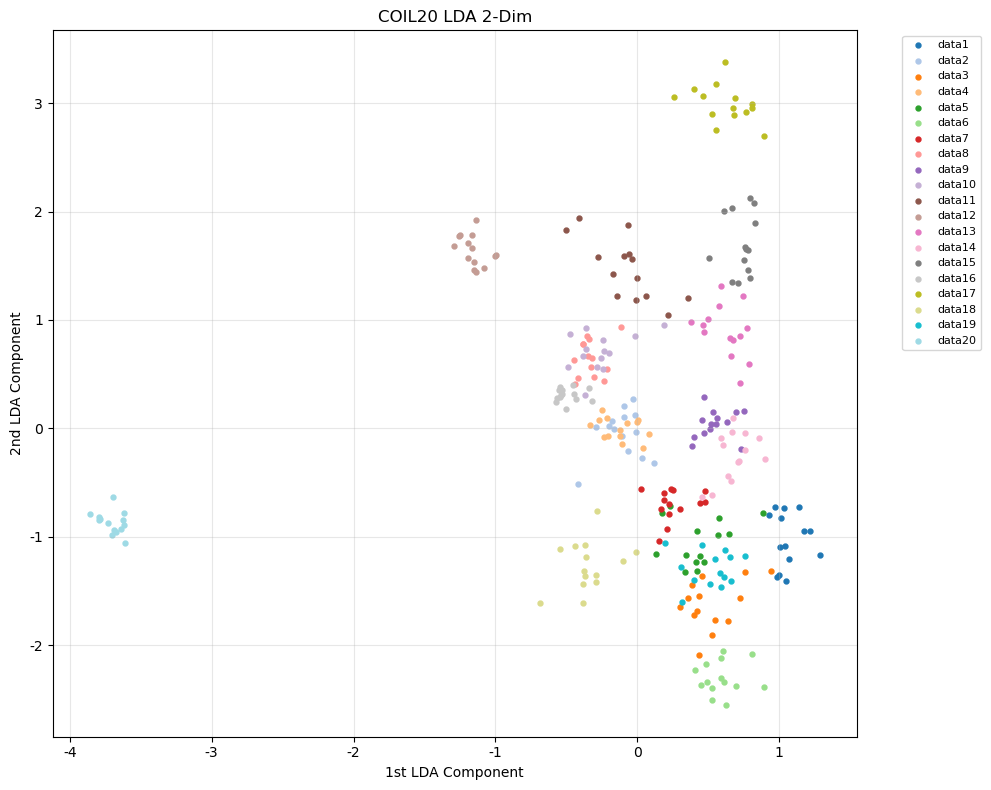

COIL20 LDA 2차원 특징 추출 결과


In [50]:
# ===== LDA 2차원 투영 및 시각화 =====

# LDA의 처음 2개 판별 벡터로 투영
W_lda_2d = eigenvectors_lda_coil[:, :2]  # (n_components_95, 2)
X_lda_2d = X_pca_95 @ W_lda_2d  # (280, 2)

print(f"LDA 2D 투영 결과 shape: {X_lda_2d.shape}")

# 클래스별 산점도
plt.figure(figsize=(10, 8))

for i, cls in enumerate(classes):
    mask = Y_train == cls
    plt.scatter(X_lda_2d[mask, 0], X_lda_2d[mask, 1],
                c=[colors[i]], marker='.', s=50,
                label=f'data{cls}')

plt.xlabel('1st LDA Component')
plt.ylabel('2nd LDA Component')
plt.title('COIL20 LDA 2-Dim')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_coil20_lda_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("COIL20 LDA 2차원 특징 추출 결과")

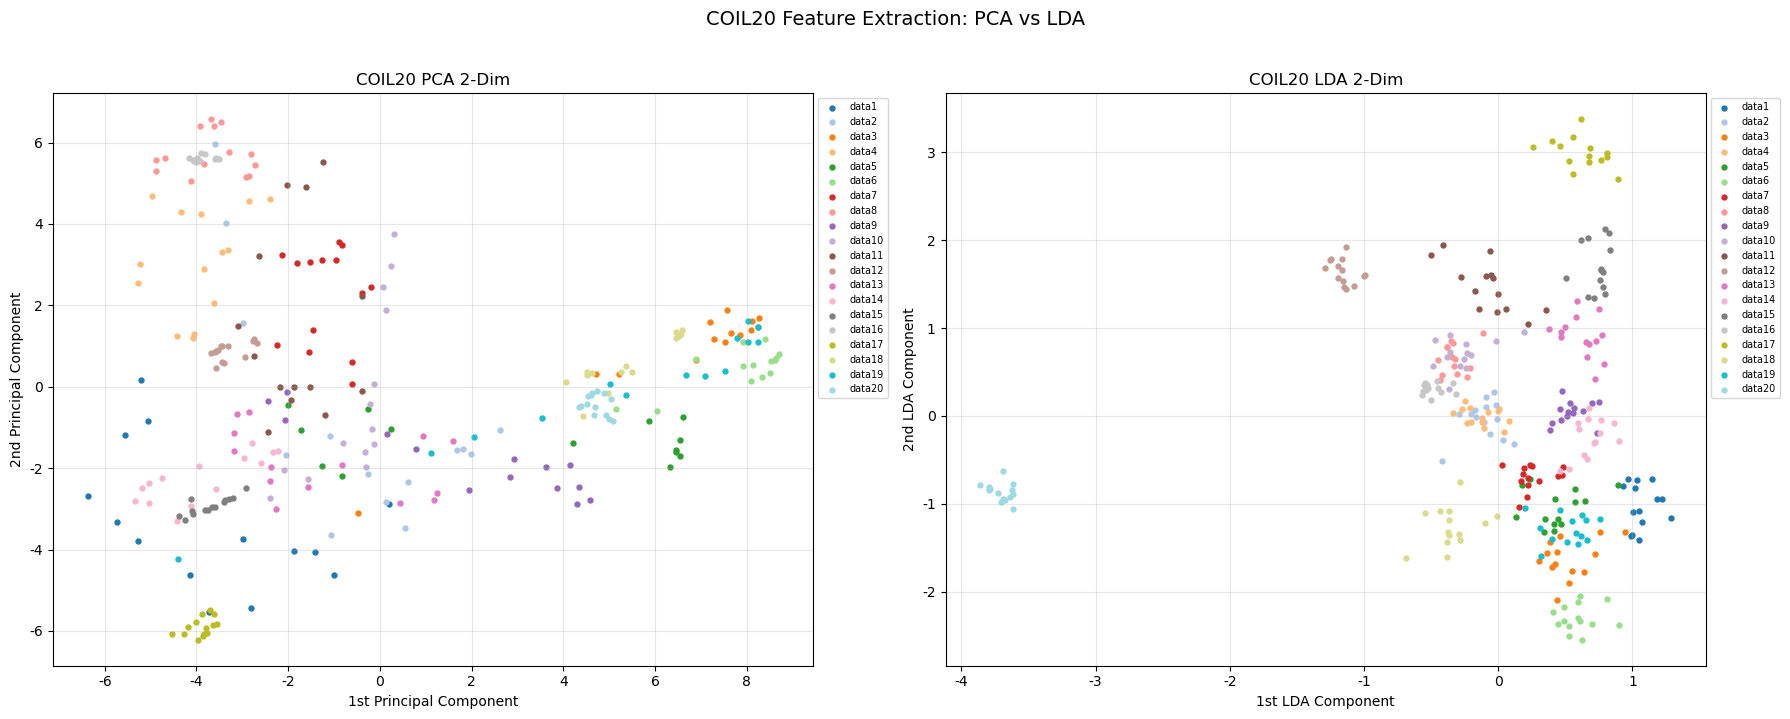

그림 3. COIL20 데이터 PCA 및 LDA 2차원 특징 추출 후 출력


In [51]:
# ===== PCA와 LDA 결과를 나란히 비교 =====

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA 2D
for i, cls in enumerate(classes):
    mask = Y_train == cls
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[colors[i]], marker='.', s=50,
                    label=f'data{cls}')
axes[0].set_xlabel('1st Principal Component')
axes[0].set_ylabel('2nd Principal Component')
axes[0].set_title('COIL20 PCA 2-Dim')
axes[0].legend(bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=7)
axes[0].grid(True, alpha=0.3)

# LDA 2D
for i, cls in enumerate(classes):
    mask = Y_train == cls
    axes[1].scatter(X_lda_2d[mask, 0], X_lda_2d[mask, 1],
                    c=[colors[i]], marker='.', s=50,
                    label=f'data{cls}')
axes[1].set_xlabel('1st LDA Component')
axes[1].set_ylabel('2nd LDA Component')
axes[1].set_title('COIL20 LDA 2-Dim')
axes[1].legend(bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.suptitle('COIL20 Feature Extraction: PCA vs LDA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig3_coil20_pca_lda_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("그림 3. COIL20 데이터 PCA 및 LDA 2차원 특징 추출 후 출력")

---
## 전체 결과 정리 및 고찰

### 문제 1 결과 요약
- 인공 데이터(2클래스, 2차원)에 대해 PCA와 LDA를 직접 구현하여 적용했습니다.
- PCA는 데이터의 분산이 큰 방향(주로 x축 방향)을 찾았고, LDA는 클래스를 잘 분리하는 방향(주로 y축 방향)을 찾았습니다.
- 1차원 투영 결과를 비교하면, LDA가 분류 목적에서는 더 효과적임을 확인할 수 있었습니다.

### 문제 2 결과 요약
- COIL20 데이터(20클래스, 1024차원)에 대해 PCA와 LDA를 적용했습니다.
- PCA 2차원 투영: 전체 분산의 일부만 보존하므로, 클래스 간 구분이 명확하지 않습니다.
- LDA 2차원 투영 (PCA 95% 전처리 후): 클래스 간 분리가 PCA에 비해 더 명확합니다.
  - LDA는 클래스 정보를 활용하므로, 같은 2차원이라도 분류에 더 유리한 표현을 찾습니다.

### 과제를 통해 배운 점
1. **PCA와 LDA의 근본적 차이**: PCA는 비지도 학습, LDA는 지도 학습. 목적이 다르므로 결과도 다릅니다.
2. **고차원 데이터에서의 실전적 문제**: Sw가 특이행렬이 되는 문제를 경험하고, PCA 전처리로 해결하는 방법을 배웠습니다.
3. **정보보존율의 의미**: 95% 정보보존이라 해도, 실제로는 상당한 차원 축소가 가능함을 확인했습니다.
4. **시각화의 중요성**: 고차원 데이터를 2차원으로 시각화하면, 데이터의 구조를 직관적으로 파악할 수 있습니다.

### 아쉬운 점 / 추후 개선할 점
- SVD를 활용한 더 효율적인 PCA 구현도 가능하다고 합니다. (대규모 데이터에서 유리)
- LDA에서 정규화(regularization) 값 epsilon을 어떻게 설정하는 것이 최적인지 더 공부가 필요합니다.
- 3차원 투영을 해보면 더 많은 정보를 보존할 수 있었을 것입니다.

---
**작성 환경:** Python 3, NumPy, Matplotlib, h5py